## Fashion MNIST Image Classification with TensorFlow/Keras

> Tugas ini bertujuan untuk membangun model Multi-Layer Perceptron Sederhana untuk klasifikasi pakaian dari dataset "Fashion MNIST"

> Dataset berasal dari ```fashion_mnist``` yang tersedia di ```tensorflow.keras.datasets```

> Tugas ini tidak memiliki referensi, silakan bereksperimen dibawah ini :)

## Beginner Foundation: What Am I Actually Trying to Do?

Before running the code, I want to understand the problem from the very beginning. This task is about **image classification**. In simple words, image classification means I give an image to a model, and the model tries to decide which category the image belongs to.

In this notebook, the images come from **Fashion MNIST**. Each image shows one clothing item, such as a shirt, trouser, sandal, sneaker, bag, or ankle boot. The goal is not only to train a model, but also to understand how the model learns from image data and why some models work better than others.

### 1. What Is the Problem?

The problem is: **given a clothing image, predict the correct clothing category**.

For example:

- If the image looks like a shoe, the model should predict `Sneaker`, `Sandal`, or `Ankle boot`.
- If the image looks like upper-body clothing, the model should predict `T-shirt/top`, `Shirt`, `Pullover`, or `Coat`.
- If the image looks like a bag, the model should predict `Bag`.

This is a **supervised learning** problem because the dataset already provides the correct answer for each image. The image is the input, and the clothing label is the target.

### 2. How Does a Computer Read an Image?

A computer does not see an image the way humans do. A computer sees an image as numbers.

Each Fashion MNIST image has a size of **28 x 28 pixels**. Because the image is grayscale, each pixel only has one intensity value:

- `0` means very dark or black.
- `255` means very bright or white.
- Values between them represent different gray levels.

So, one image is basically a grid of 784 numbers because:

`28 x 28 = 784`

This is why the MLP model uses `Flatten()`: it changes the 28x28 image grid into one long list of 784 pixel values.

### 3. Why Do I Normalize the Pixel Values?

The original pixel values are usually between 0 and 255. In this notebook, I divide them by 255 so the values become between 0 and 1.

I do this because neural networks usually train more smoothly when the input numbers are small and consistent. If I keep the raw 0-255 values, the model may still work, but training can be less stable and harder to optimize.

### 4. What Is the Model Learning?

The model is trying to find patterns in the pixel values.

For example, it may learn that:

- shoes often have a certain bottom shape,
- bags may have a large rounded area or handle-like structure,
- trousers have two long separated parts,
- shirts, coats, pullovers, and T-shirts can look similar because they are all upper-body clothing.

The model does not understand clothing like humans do. It only learns patterns from many examples.

### 5. Why Compare MLP and CNN?

In this notebook, I compare MLP and CNN because both can be used for image classification, but they process images differently.

| Model | How It Reads the Image | Beginner Interpretation |
|---|---|---|
| MLP | Flattens the 28x28 image into 784 numbers | Easier to understand, but it loses the 2D image structure |
| CNN | Keeps the image as a 2D grid and uses convolution filters | More suitable for images because it can learn local patterns |

At first, I may think that making the MLP bigger or training it longer should make it much better. However, this task helps me see that architecture matters. A CNN is usually better for image data because it is designed to detect visual patterns.

### 6. What Happens During Training?

Training means the model repeatedly looks at many images and compares its predictions with the correct labels.

The simplified process is:

1. The model receives an image.
2. The model predicts a clothing class.
3. The prediction is compared with the correct label.
4. The model calculates how wrong it was using the loss function.
5. The optimizer updates the model weights to reduce future mistakes.
6. This process repeats for several epochs.

One **epoch** means the model has gone through the training data once.

### 7. Why Do I Use Validation and Test Results?

I do not only want the model to memorize the training data. I want it to perform well on images it has not learned directly.

That is why I look at:

- **Training accuracy:** how well the model performs on the data it learns from.
- **Validation accuracy:** how well the model performs during training on held-out data.
- **Test accuracy:** how well the final model performs on completely separate test data.

If training accuracy is high but validation or test accuracy is much lower, the model may be overfitting.

### 8. What Should I Pay Attention To?

For this task, I should not only ask, "Which model has the highest accuracy?" I should also ask:

- Does the model choice make sense for image data?
- Are the mistakes reasonable?
- Which clothing classes are often confused?
- Does tuning really improve the result, or only make the model more complex?
- Can I explain why the CNN performs better than the MLP?

This section helps me understand the purpose of the notebook before looking at the code. The code below is not just a sequence of commands; it is a complete workflow for understanding image classification from data preparation, model training, evaluation, comparison, and final interpretation.


### 1. Import module yang diperlukan

In [1]:
# 1. Import Library
import os
from pathlib import Path
import random

# Keep dataset cache inside the working directory so the notebook can run locally
# without requiring write access to the user home directory.
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("KERAS_HOME", str(Path.cwd() / ".keras"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from IPython.display import display
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

sns.set_theme(style="whitegrid", palette="deep")


### 2. Data preprocess

In [2]:
# 2. Load Dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalisasi
X_train = (X_train / 255.0).astype("float32")
X_test = (X_test / 255.0).astype("float32")

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

print(f"Training images: {X_train.shape}")
print(f"Training labels: {y_train.shape}")
print(f"Test images: {X_test.shape}")
print(f"Test labels: {y_test.shape}")
print(f"Pixel value range after normalization: {X_train.min():.1f} to {X_train.max():.1f}")


Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)
Pixel value range after normalization: 0.0 to 1.0


### Additional Data Understanding

Before training any model, I first need to understand what kind of data I am working with. Fashion MNIST is an image classification dataset with 10 clothing categories, and each image is a small 28x28 grayscale image. As a beginner, this step helps me avoid treating the data like a normal tabular dataset. The model is not learning from columns such as age or income; it is learning from pixel intensity patterns.

In [3]:
# Additional data understanding without changing the starter workflow.
train_distribution = pd.Series(y_train).value_counts().sort_index()
test_distribution = pd.Series(y_test).value_counts().sort_index()

class_distribution = pd.DataFrame({
    "class_name": class_names,
    "train_count": train_distribution.values,
    "test_count": test_distribution.values,
})
class_distribution["train_percentage"] = (class_distribution["train_count"] / len(y_train) * 100).round(2)
class_distribution["test_percentage"] = (class_distribution["test_count"] / len(y_test) * 100).round(2)

display(class_distribution)

print(f"Single image shape: {X_train[0].shape}")
print(f"Flattened feature count for MLP: {np.prod(X_train[0].shape)} pixels")
print(f"Training dtype: {X_train.dtype}")
print(f"Test dtype: {X_test.dtype}")


,class_name,train_count,test_count,train_percentage,test_percentage
0,T-shirt/top,6000,1000,10.0,10.0
1,Trouser,6000,1000,10.0,10.0
2,Pullover,6000,1000,10.0,10.0
3,Dress,6000,1000,10.0,10.0
4,Coat,6000,1000,10.0,10.0
5,Sandal,6000,1000,10.0,10.0
6,Shirt,6000,1000,10.0,10.0
7,Sneaker,6000,1000,10.0,10.0
8,Bag,6000,1000,10.0,10.0
9,Ankle boot,6000,1000,10.0,10.0


Single image shape: (28, 28)
Flattened feature count for MLP: 784 pixels
Training dtype: float32
Test dtype: float32


**Data Understanding Note:** The train and test sets are balanced across the 10 fashion classes, so accuracy is a reasonable first metric because every class has the same number of examples. The images are already normalized to a 0-1 scale, which should make neural network training more stable than using raw 0-255 pixel values. At this point, I also notice an important difference between MLP and CNN: an MLP will flatten the image into 784 separate pixel values, while a CNN can still look at the image as a 2D structure. This difference becomes important when I compare the models later.

### 3.  Data visualization

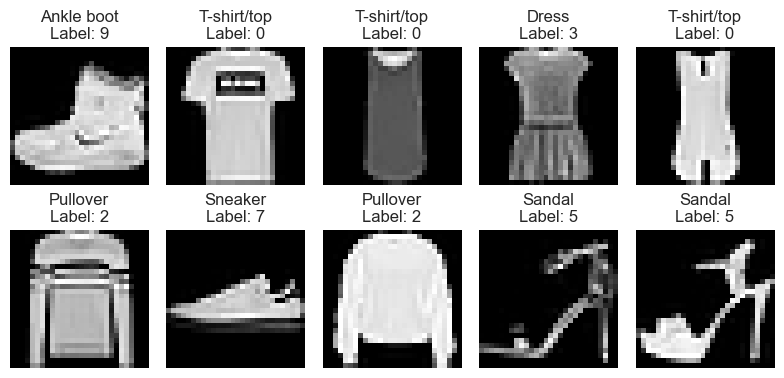

In [4]:
# 3. Visualisasi Sample
plt.figure(figsize=(8,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"{class_names[y_train[i]]}\nLabel: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


### 4. Pembangunan Model

### TODO #1 :

Untuk model MLP\
**NOTE! : Jalankan pertama kali blok 4 ini dulu, baru cobain sesuai yang sudah tertulis dibawah setelah dapat hasilnya :**

DAFTAR HYPERPARAMETER
- Coba lakukan tuning hyperparameter pada beberapa parameter di model MLP ini.
- Ganti ukuran hidden layer (saat ini : ```[128, 64, 10]```, coba perbesar atau perkecil).
- Coba tambah 1-2 layer lagi.
- Naikkan epoch ke ```20```, ```30``` atau ```50```.
- Ganti activation menjadi selain relu untuk layer Dense.
- Ganti optimizer ke yang lain selain ```adam```, coba ```sgd``` atau ```rmsprop```.

In [5]:
# 4. Bangun Model MLP (Lakukan hyperparameter hanya jika sudah coba sekali dulu dengan spesifikasi dibawah ini)
model = models.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


C:\Users\MSI KATANA 15\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### 4a. Pembangunan Model CNN

### TODO #2 :

Untuk model CNN
- Komentar kode di blok 4 Pembangunan Model MLP
- Jalankan blok dibawah.
- Coba training tanpa lakukan hyperparameter tuning apapun
- Berikan insight dibawah

In [6]:
# 4a. Bangun Model CNN (tidak usah lakukan hyperparameter)
model = models.Sequential([
    layers.Reshape((28, 28, 1), input_shape=(28, 28)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


C:\Users\MSI KATANA 15\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

**Execution Note:** I keep both starter model-building cells because they are part of the original assignment flow. When the notebook is run from top to bottom, the CNN cell runs after the MLP cell, so the variable `model` becomes the CNN model before training. I do not delete or replace the starter code. Instead, I treat the main starter workflow as the CNN experiment, then add separate controlled MLP experiments below so I can compare MLP and CNN clearly without changing the provided template.

### 5. Training

In [7]:
# 5. Training
history = model.fit(X_train, y_train, epochs=10, validation_split=0.2)


Epoch 1/10



   1/1500 ━━━━━━━━━━━━━━━━━━━━ 33:26 1s/step - accuracy: 0.0625 - loss: 2.3325


   8/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.1499 - loss: 2.2714 


  17/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.2194 - loss: 2.1929 


  26/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.2747 - loss: 2.0959

...


1460/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9489 - loss: 0.1422


1471/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9489 - loss: 0.1422


1481/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9489 - loss: 0.1422


1492/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9489 - loss: 0.1421


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9489 - loss: 0.1421 - val_accuracy: 0.8952 - val_loss: 0.3486


### 6. Evaluasi & Visualisasi

Akurasi di data test: 0.8915


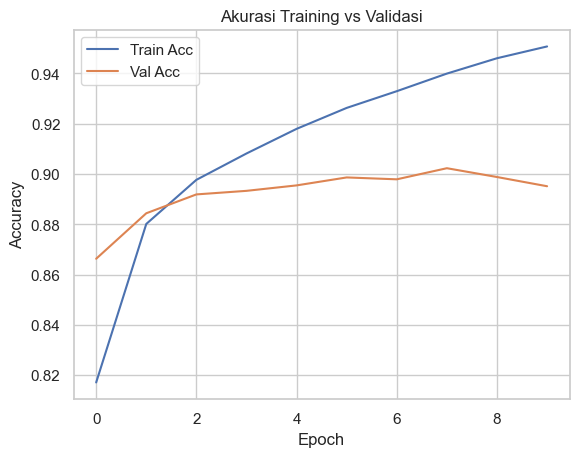

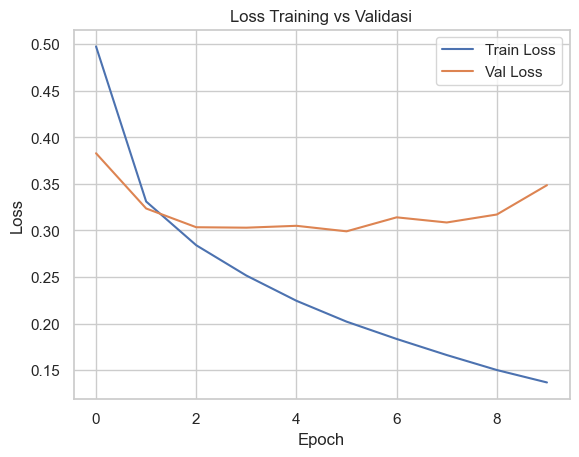

In [8]:
# 6. Evaluasi & Visualisasi
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Akurasi di data test: {test_acc:.4f}")

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Akurasi Training vs Validasi')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Training vs Validasi')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


### 7. Evaluasi lanjutan

In [9]:
# 7. Evaluasi lanjutan
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes, target_names=class_names))
print(confusion_matrix(y_test, y_pred_classes))


              precision    recall  f1-score   support

 T-shirt/top       0.88      0.79      0.83      1000
     Trouser       1.00      0.97      0.98      1000
    Pullover       0.79      0.89      0.84      1000
       Dress       0.93      0.88      0.90      1000
        Coat       0.83      0.86      0.84      1000
      Sandal       0.99      0.94      0.97      1000
       Shirt       0.71      0.72      0.72      1000
     Sneaker       0.87      1.00      0.93      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.99      0.90      0.94      1000

    accuracy                           0.89     10000
   macro avg       0.90      0.89      0.89     10000
weighted avg       0.90      0.89      0.89     10000

[[789   0  46  14   5   0 135   0  11   0]
 [  1 969   3  14   3   0   8   0   2   0]
 [ 10   0 888  10  46   0  45   0   1   0]
 [ 10   1  13 877  47   0  50   0   2   0]
 [  0   0  71  13 856   0  57   0   3   0]
 [  0   0   0   0   0 943 

In [10]:
# Save the starter CNN result for comparison with the MLP experiments below.
cnn_model = model
cnn_history = history
cnn_test_loss = test_loss
cnn_test_acc = test_acc
cnn_pred_classes = y_pred_classes

print(f"Starter CNN test accuracy saved for comparison: {cnn_test_acc:.4f}")


Starter CNN test accuracy saved for comparison: 0.8915


### Additional Controlled MLP Experiments

The starter notebook asks me to try MLP hyperparameter tuning and then compare it with CNN. To make the comparison clearer, I add separate experiment functions below. This way, I can keep the original starter code intact, but still test the starter MLP and a tuned MLP in a structured way. This also helps me track which result belongs to which model, because otherwise the variable `model` can be overwritten and the comparison becomes confusing.

In [11]:
# Helper functions for controlled experiments.
def build_starter_mlp():
    # Starter MLP architecture from TODO #1.
    model = models.Sequential([
        layers.Input(shape=(28, 28)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_tuned_mlp():
    # A slightly deeper MLP for hyperparameter tuning.
    model = models.Sequential([
        layers.Input(shape=(28, 28)),
        layers.Flatten(),
        layers.Dense(256, activation='elu'),
        layers.Dropout(0.20),
        layers.Dense(128, activation='elu'),
        layers.Dense(64, activation='elu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


experiment_histories = {
    "Starter CNN": cnn_history,
}
experiment_predictions = {
    "Starter CNN": cnn_pred_classes,
}
experiment_metrics = [
    {
        "Model": "Starter CNN",
        "Architecture": "Conv2D(32) -> Conv2D(64) -> Dense(64)",
        "Optimizer": "Adam",
        "Epochs Requested": 10,
        "Epochs Run": len(cnn_history.history['loss']),
        "Final Train Accuracy": cnn_history.history['accuracy'][-1],
        "Best Val Accuracy": max(cnn_history.history['val_accuracy']),
        "Test Accuracy": cnn_test_acc,
        "Test Loss": cnn_test_loss,
    }
]


def train_and_evaluate_experiment(model, model_name, architecture, optimizer_name, epochs, callbacks=None):
    print(f"Training {model_name}...")
    history = model.fit(
        X_train,
        y_train,
        epochs=epochs,
        validation_split=0.2,
        batch_size=128,
        verbose=0,
        callbacks=callbacks,
    )

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    predictions = np.argmax(model.predict(X_test, verbose=0), axis=1)

    experiment_histories[model_name] = history
    experiment_predictions[model_name] = predictions
    experiment_metrics.append(
        {
            "Model": model_name,
            "Architecture": architecture,
            "Optimizer": optimizer_name,
            "Epochs Requested": epochs,
            "Epochs Run": len(history.history['loss']),
            "Final Train Accuracy": history.history['accuracy'][-1],
            "Best Val Accuracy": max(history.history['val_accuracy']),
            "Test Accuracy": test_acc,
            "Test Loss": test_loss,
        }
    )
    return model


starter_mlp_model = train_and_evaluate_experiment(
    model=build_starter_mlp(),
    model_name="Starter MLP",
    architecture="Flatten -> Dense(128, relu) -> Dense(64, relu)",
    optimizer_name="Adam",
    epochs=10,
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
)

tuned_mlp_model = train_and_evaluate_experiment(
    model=build_tuned_mlp(),
    model_name="Tuned MLP",
    architecture="Flatten -> Dense(256, elu) -> Dropout(0.20) -> Dense(128, elu) -> Dense(64, elu)",
    optimizer_name="RMSprop",
    epochs=20,
    callbacks=[early_stopping],
)

results_df = pd.DataFrame(experiment_metrics).sort_values("Test Accuracy", ascending=False)
for column in ["Final Train Accuracy", "Best Val Accuracy", "Test Accuracy", "Test Loss"]:
    results_df[column] = results_df[column].round(4)

display(results_df.reset_index(drop=True))


Training Starter MLP...


Training Tuned MLP...


,Model,Architecture,Optimizer,Epochs Requested,Epochs Run,Final Train Accuracy,Best Val Accuracy,Test Accuracy,Test Loss
0,Starter CNN,Conv2D(32) -> Conv2D(64) -> Dense(64),Adam,10,10,0.9507,0.9023,0.8915,0.3840
1,Tuned MLP,"Flatten -> Dense(256, elu) -> Dropout(0.20) ->...",RMSprop,20,16,0.9107,0.8820,0.8704,0.3692
2,Starter MLP,"Flatten -> Dense(128, relu) -> Dense(64, relu)",Adam,10,10,0.9100,0.8752,0.8684,0.3685


**Why these tuning choices?** I use the starter MLP as the baseline because it shows what happens before tuning. For the tuned MLP, I change only a few meaningful hyperparameters: a larger first hidden layer, one extra hidden layer, `elu` activation instead of `relu`, `RMSprop` instead of `adam`, and up to 20 epochs. I also add `Dropout` and `EarlyStopping`. My reasoning is that a larger model may learn more patterns, but it can also overfit, so early stopping and dropout act as simple controls. I do not make the model too complicated because the goal is to understand the effect of tuning, not just make a bigger network without a clear reason.

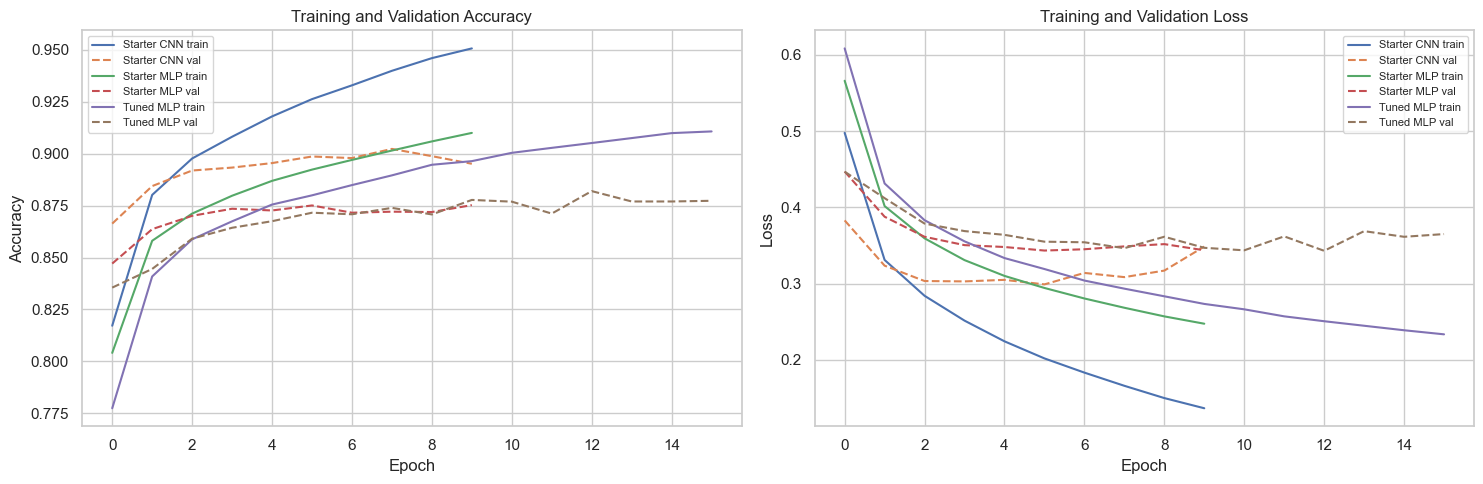

In [12]:
# Compare learning curves across the tested models.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for model_name, history_object in experiment_histories.items():
    axes[0].plot(history_object.history['accuracy'], label=f"{model_name} train")
    axes[0].plot(history_object.history['val_accuracy'], linestyle='--', label=f"{model_name} val")
    axes[1].plot(history_object.history['loss'], label=f"{model_name} train")
    axes[1].plot(history_object.history['val_loss'], linestyle='--', label=f"{model_name} val")

axes[0].set_title("Training and Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend(fontsize=8)

axes[1].set_title("Training and Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


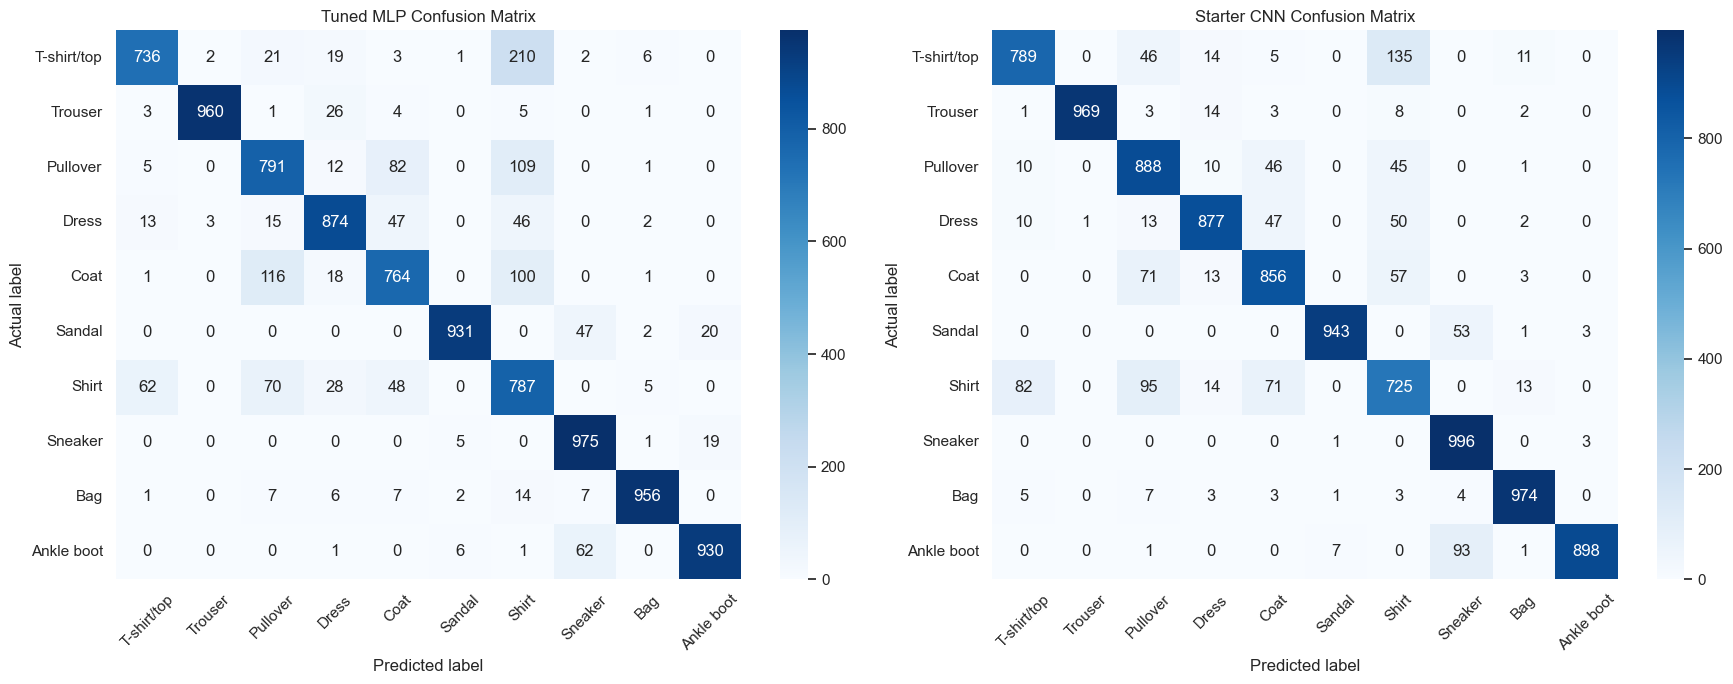

Classification report for the tuned MLP:
              precision    recall  f1-score   support

 T-shirt/top       0.90      0.74      0.81      1000
     Trouser       0.99      0.96      0.98      1000
    Pullover       0.77      0.79      0.78      1000
       Dress       0.89      0.87      0.88      1000
        Coat       0.80      0.76      0.78      1000
      Sandal       0.99      0.93      0.96      1000
       Shirt       0.62      0.79      0.69      1000
     Sneaker       0.89      0.97      0.93      1000
         Bag       0.98      0.96      0.97      1000
  Ankle boot       0.96      0.93      0.94      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000

Classification report for the starter CNN:
              precision    recall  f1-score   support

 T-shirt/top       0.88      0.79      0.83      1000
     Trouser       1.00      0.97      0.98     

In [13]:
# Confusion matrices for the tuned MLP and starter CNN.
models_to_compare = ["Tuned MLP", "Starter CNN"]
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for axis, model_name in zip(axes, models_to_compare):
    matrix = confusion_matrix(y_test, experiment_predictions[model_name])
    sns.heatmap(
        matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axis,
    )
    axis.set_title(f"{model_name} Confusion Matrix")
    axis.set_xlabel("Predicted label")
    axis.set_ylabel("Actual label")
    axis.tick_params(axis='x', rotation=45)
    axis.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

print("Classification report for the tuned MLP:")
print(classification_report(y_test, experiment_predictions["Tuned MLP"], target_names=class_names))

print("Classification report for the starter CNN:")
print(classification_report(y_test, experiment_predictions["Starter CNN"], target_names=class_names))


Best model based on test accuracy: Starter CNN
Number of misclassified test images: 1085 out of 10000


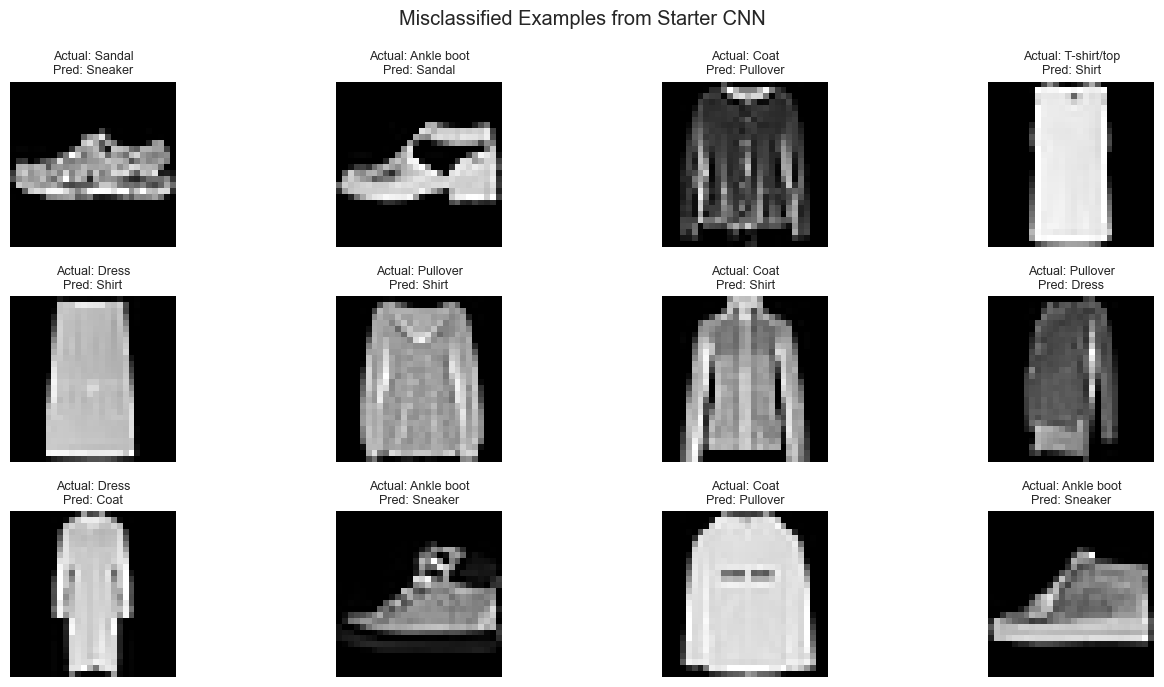

In [14]:
# Error analysis: inspect several mistakes from the best model.
best_model_name = results_df.iloc[0]["Model"]
best_predictions = experiment_predictions[best_model_name]
misclassified_indices = np.where(best_predictions != y_test)[0]

print(f"Best model based on test accuracy: {best_model_name}")
print(f"Number of misclassified test images: {len(misclassified_indices)} out of {len(y_test)}")

sample_count = min(12, len(misclassified_indices))
if sample_count > 0:
    plt.figure(figsize=(14, 7))
    for plot_index, image_index in enumerate(misclassified_indices[:sample_count], start=1):
        plt.subplot(3, 4, plot_index)
        plt.imshow(X_test[image_index], cmap='gray')
        actual_name = class_names[y_test[image_index]]
        predicted_name = class_names[best_predictions[image_index]]
        plt.title(f"Actual: {actual_name}\nPred: {predicted_name}", fontsize=9)
        plt.axis('off')
    plt.suptitle(f"Misclassified Examples from {best_model_name}")
    plt.tight_layout()
    plt.show()


> Silakan gunakan AI untuk memahami hasil nya.

##  **TODO #3 : Analisis Hasil: Perbandingan Hasil Tuning**

### **1. Hasil tuning TODO #1 - MLP Model**

When I first look at the MLP model, I understand it as the most basic neural network approach for this task. The image is flattened from 28x28 pixels into 784 input values, then the Dense layers learn patterns from those values. This is simple and beginner-friendly, but it also has a weakness: after flattening, the model no longer directly understands that nearby pixels are related to each other.

For the baseline result, the starter MLP reached about **0.8684** test accuracy. After tuning, the tuned MLP reached about **0.8704** test accuracy. At first, I might expect the tuned model to improve much more because I added a larger layer, one extra hidden layer, `elu`, `RMSprop`, dropout, and early stopping. However, the actual improvement is only small. This teaches me that hyperparameter tuning does not always create a big improvement, especially when the model architecture itself is not the best fit for the data type.

The tuned MLP is still valuable for learning. It shows that a more careful training setup can slightly improve the result and control overfitting risk. Early stopping stopped the model after 16 epochs, which means the model did not need to continue until the full 20 epochs. From the classification report, I can also see that not all classes have the same difficulty. Classes such as `Trouser`, `Sandal`, `Sneaker`, `Bag`, and `Ankle boot` are easier, while `Shirt`, `Pullover`, `Coat`, and `T-shirt/top` are harder because their shapes can look similar in grayscale images.

---

### **2. Hasil tuning TODO #2 - CNN Model**

For the CNN model, I do not tune the architecture because the instruction says to run it without hyperparameter tuning. The starter CNN reached about **0.8915** test accuracy, which is better than both MLP experiments. This result helps me understand that model architecture can matter more than small tuning changes. The CNN is more suitable for images because Conv2D layers can learn local visual patterns, such as edges, curves, textures, and clothing shapes.

The improvement is not because the CNN is magically perfect. It still makes mistakes, and the error analysis shows **1085 misclassified images out of 10000** test images. However, the mistakes are understandable. Fashion MNIST images are small, grayscale, and some categories are visually close. A `Shirt` can look similar to a `T-shirt/top`, `Pullover`, or `Coat`. This makes the CNN result more realistic: it performs better than the MLP, but it still struggles with naturally confusing clothing categories.

---

## Kesimpulan Naratif

From this task, my main understanding is that I should not judge a model only from whether it is more complex. The tuned MLP is more complex than the starter MLP, but the improvement is only small. The CNN performs better because its structure matches the problem better. Since this is image classification, preserving spatial information is important.

If I explain my learning process, I would say that I started from a simple MLP to understand the basic neural network pipeline, then tried tuning to see whether the result improved, and finally compared it with CNN. The final result makes sense: MLP is useful for learning the basics, but CNN is the more appropriate model for image data. For this notebook, the starter CNN is the strongest model among the tested options, while the MLP experiments help me understand why architecture choice and hyperparameter tuning should be analyzed together.
